<a href="https://colab.research.google.com/github/KBM5703/2111464_Tran-Vi-Khang/blob/main/Khang_ISSAS25_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP REPO

In [1]:
!pip install -q ipympl

In [2]:
from google.colab import userdata
GITHUB_PAT=userdata.get('GITHUB_PAT')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import sys

# Cấu hình GitHub
GITHUB_REPO = 'hieuphmm/ISAS_Challenge2025'
REPO_DIR = os.path.basename(GITHUB_REPO)
BRANCH = "exp/khang"

# Clone repo
%cd /content
!git clone https://{GITHUB_PAT}@github.com/{GITHUB_REPO}.git {REPO_DIR}
%cd {REPO_DIR}

# Tạo nhánh nếu chưa có (checkout -b để tạo mới)
!git checkout -b {BRANCH}

# Push nhánh mới lên GitHub
!git push -u origin {BRANCH}

# Thêm repo vào sys.path để import module nội bộ
sys.path.append(os.getcwd())

/content
fatal: destination path 'ISAS_Challenge2025' already exists and is not an empty directory.
/content/ISAS_Challenge2025
fatal: A branch named 'exp/khang' already exists.
To https://github.com/hieuphmm/ISAS_Challenge2025.git
 ! [rejected]        exp/khang -> exp/khang (non-fast-forward)
error: failed to push some refs to 'https://github.com/hieuphmm/ISAS_Challenge2025.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


# SIMPLE WORKFLOW

## 1. Import and data

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/ISAS_Challenge2025']

In [7]:
import os
import sys

import numpy as np
import pandas as pd
from src import DATA_DIR
from src.constants import ACTIVITY_LABEL_MAP, SEQUENCE_LENGTH
from src.constants import SEQUENCE_LENGTH_IN_WINDOW, WINDOW_OVERLAP_RATE, WINDOW_SIZE
from src.utils import create_sequences

import torch
import torch.nn
from torch.utils.data import Dataset, DataLoader
import gdown


In [8]:
CHALLENGE_DATA_DIR = os.path.join(DATA_DIR)  # /content/ISAS_Challenge2025/data

KEYPOINT_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypoint-20250616T140515Z-1-001", "keypoint")
KEYPOINT_LABEL_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypointlabel-20250616T140517Z-1-001", "keypointlabel")
TIME_TABLE_DIR = os.path.join(CHALLENGE_DATA_DIR, "timetable-20250616T140520Z-1-001", "timetable")

print(KEYPOINT_DIR, os.path.exists(KEYPOINT_DIR))
print(KEYPOINT_LABEL_DIR, os.path.exists(KEYPOINT_LABEL_DIR))
print(TIME_TABLE_DIR, os.path.exists(TIME_TABLE_DIR))


/content/ISAS_Challenge2025/data/keypoint-20250616T140515Z-1-001/keypoint True
/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel True
/content/ISAS_Challenge2025/data/timetable-20250616T140520Z-1-001/timetable True


In [9]:
# download dataset
DATASET_URL = "https://drive.google.com/drive/folders/1xXo0dPWcPAwDQsXJGNEYofeFOO2iBtM6?usp=sharing"
if os.path.exists(KEYPOINT_DIR) and os.path.exists(KEYPOINT_LABEL_DIR):
    print("Dataset already downloaded")
else:
    print("Downloading dataset...")
    _ = gdown.download_folder(url=DATASET_URL, output=DATA_DIR)

Dataset already downloaded


## 2. Data exploration

### 2.1 Visualization

In [10]:
csv_paths = []
for r, _, fs in os.walk(KEYPOINT_LABEL_DIR):
    for f in fs:
        csv_paths.append(os.path.join(r, f))
    break
csv_paths = sorted(csv_paths)
csv_paths

['/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_1.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_2.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_3.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_5.csv']

In [11]:
test_path = csv_paths[0]
df = pd.read_csv(test_path)
df.head()

,frame_id,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,...,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,Action Label
0,0,624.0,258.25,628.0,249.50,625.0,249.750,650.5,252.250,667.5,...,441.00,656.5,535.0,724.0,528.0,634.5,616.5,746.5,612.0,Walking
1,1,618.0,260.00,621.5,251.25,618.5,251.625,644.0,254.375,660.5,...,440.00,651.0,533.5,720.0,526.5,627.5,616.0,746.0,610.5,Walking
2,2,611.5,260.50,615.0,252.00,613.0,252.250,637.0,256.000,656.5,...,441.00,644.5,533.0,715.5,525.5,625.5,616.5,746.0,609.5,Walking
3,3,604.0,261.00,608.0,252.50,605.5,252.750,630.5,256.000,648.5,...,443.00,639.0,535.0,710.5,525.5,623.0,618.0,745.5,608.0,Walking
4,4,598.0,260.00,602.5,252.00,600.0,252.000,623.0,256.750,642.5,...,444.25,634.5,539.0,703.0,525.5,620.5,619.0,742.5,605.5,Walking


In [12]:
value = df.drop(columns=["frame_id", "Action Label"])
value = value.values
value.shape, value[0]

((76456, 34),
 array([624.   , 258.25 , 628.   , 249.5  , 625.   , 249.75 , 650.5  ,
        252.25 , 667.5  , 249.125, 666.   , 309.5  , 691.5  , 297.5  ,
        674.   , 391.   , 696.   , 380.   , 673.   , 463.   , 679.   ,
        448.5  , 678.   , 447.   , 707.5  , 441.   , 656.5  , 535.   ,
        724.   , 528.   , 634.5  , 616.5  , 746.5  , 612.   ]))

In [13]:
from google.colab import output
output.enable_custom_widget_manager()

interactive(children=(IntSlider(value=0, description='Frame', layout=Layout(width='600px'), max=76455), Output…

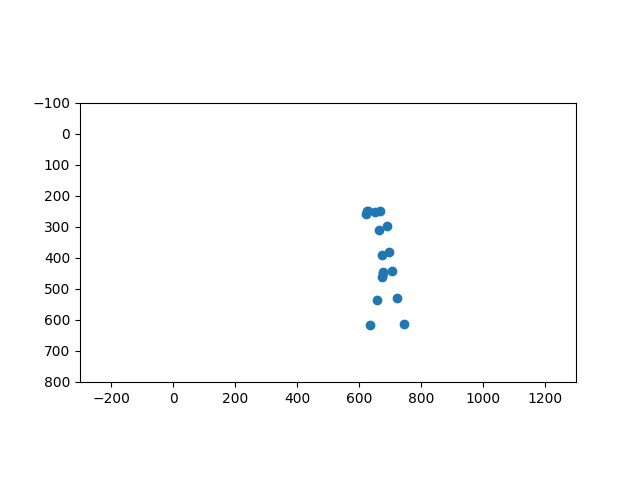

In [14]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, Play, VBox, HBox, jslink, Dropdown, BoundedIntText
from IPython.display import display

# --- Matplotlib setup ---
fig, ax = plt.subplots()
sc = ax.scatter([], [])  # init scatter
sc.set_offsets(np.column_stack((value[0, 0::2], value[0, 1::2])))  # <- THÊM DÒNG NÀY

ax.set_xlim(-300, 1300)
ax.set_ylim(-100, 800)
ax.invert_yaxis()
ax.axis('scaled')

# --- Widgets ---
slider = IntSlider(value=0, min=0, max=len(value)-1, description='Frame', layout={'width': '600px'})
play = Play(min=0, max=len(value)-1, interval=33, step=1, layout={'width': '600px'})

speed_dropdown = Dropdown(
    options=[('🐢 15 FPS', 67), ('🏃 30 FPS', 33), ('🚀 60 FPS', 17), ('⚡ Ultra Fast', 1)],
    value=33,
    description='Speed:',
    layout={'width': '300px'}
)

step_spinner = BoundedIntText(
    value=1, min=1, max=100, step=1,
    description='Frame step:', layout={'width': '200px'}
)

# --- Event bindings ---
def on_speed_change(change): play.interval = change['new']
def on_skip_change(change): play.step = change['new']

speed_dropdown.observe(on_speed_change, names='value')
step_spinner.observe(on_skip_change, names='value')
jslink((play, 'value'), (slider, 'value'))

# --- Update function ---
def update(idx):
    sc.set_offsets(np.column_stack((value[idx, 0::2], value[idx, 1::2])))
    fig.canvas.draw_idle()

interact(update, idx=slider)
display(VBox([slider, play, HBox([speed_dropdown, step_spinner])]))


In [15]:
from google.colab import output
output.disable_custom_widget_manager()

### 2.2 Data processing

In [16]:
print(ACTIVITY_LABEL_MAP)

def fix_label(label:str):
    if label == "Throwing":
        return "Throwing things"
    return label

{0: 'Sitting quietly', 1: 'Using phone', 2: 'Walking', 3: 'Eating snacks', 4: 'Head banging', 5: 'Throwing things', 6: 'Attacking', 7: 'Biting'}


In [17]:
# fix label Throwing -> Throwing things
csv_dir = KEYPOINT_LABEL_DIR
out_dir = os.path.join(CHALLENGE_DATA_DIR, "keypointlabelcleaned")
os.makedirs(out_dir, exist_ok=True)

cleaned_csv_paths = []
# total_df = pd.DataFrame()
for filename in os.listdir(csv_dir):
    csv_path = os.path.join(csv_dir, filename)
    df = pd.read_csv(csv_path)
    df["Action Label"] = df["Action Label"].apply(fix_label)
    df = df.dropna()  # DROP NA

    dst = f"cleaned_{filename}"
    dst = os.path.join(out_dir, dst)
    cleaned_csv_paths.append(dst)
    df.to_csv(dst,index=False)
    # total_df = pd.concat([total_df, df])

cleaned_csv_paths = sorted(cleaned_csv_paths)

In [18]:
def process_data(
    df: pd.DataFrame,
    window_size: int,
    sequence_length_in_window: int,
    window_overlap_rate: float = 0.5,
    window_padding: bool = True,
    sequence_overlap_rate: float = 0.0,
    sequence_padding: bool = True,
):
    # df = pd.read_csv(cleaned_csv_paths[0])
    def _create_sequences(data):
        return create_sequences(
            data=data,
            window_size=window_size,
            sequence_length_in_window=sequence_length_in_window,
            window_overlap_rate=window_overlap_rate,
            window_padding=sequence_padding,
            sequence_overlap_rate=sequence_overlap_rate,
            sequence_padding=window_padding,
        )

    frame_id = df["frame_id"].values
    diff = frame_id[1:] - frame_id[:-1]
    diff_idx = np.flatnonzero(diff != 1) + 1

    labels = df["Action Label"].values
    features = df[df.columns[1:-1]]  # remove "frame_id" and "Actual Label"

    XY = []
    for i in range(0, len(diff_idx) - 1):
        first_idx, last_idx = diff_idx[i], diff_idx[i + 1]
        sequences = _create_sequences(features[first_idx:last_idx])
        Y = [labels[first_idx]] * sequences.shape[0]
        XY.append((sequences, Y))
    # 1st sequence
    sequences = _create_sequences(data=features[: diff_idx[0]])
    Y = [labels[0]] * sequences.shape[0]
    XY.insert(0, (sequences, Y))
    # last squence
    sequences = _create_sequences(data=features[diff_idx[-1] :])
    Y = [labels[-1]] * sequences.shape[0]
    XY.append((sequences, Y))
    return XY

In [19]:
print(cleaned_csv_paths[0])
df = pd.read_csv(cleaned_csv_paths[0])
XY = process_data(
    df=df,
    window_size=WINDOW_SIZE,
    sequence_length_in_window=SEQUENCE_LENGTH_IN_WINDOW,
    window_overlap_rate=WINDOW_OVERLAP_RATE,
    window_padding=True,
    sequence_overlap_rate=0,
    sequence_padding=False,
)

/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_1.csv


In [20]:
for X, Y in XY:
    print(X.shape)
    print(X)
    print(len(Y))
    print(Y[0], Y[-1])
    break

(164, 3, 30, 34)
[[[[624.      258.25    628.      ... 616.5     746.5     612.     ]
   [618.      260.      621.5     ... 616.      746.      610.5    ]
   [611.5     260.5     615.      ... 616.5     746.      609.5    ]
   ...
   [440.75    268.      444.      ... 591.5     516.      596.     ]
   [434.5     269.25    437.5     ... 592.      518.      597.     ]
   [429.      268.5     432.      ... 594.      520.5     595.     ]]

  [[517.5     264.      521.      ... 615.5     609.5     581.5    ]
   [510.      265.      514.      ... 611.5     596.      588.     ]
   [502.75    265.25    506.25    ... 614.      574.      590.     ]
   ...
   [348.      278.      351.5     ... 603.      504.      579.     ]
   [341.      277.25    344.      ... 604.      496.75    574.5    ]
   [334.25    278.5     337.      ... 607.      489.      570.     ]]

  [[425.      268.5     427.5     ... 588.      526.5     587.     ]
   [417.25    269.      420.5     ... 595.      518.5     592.     ]

### ST_GCN

In [21]:
!pip install torchinfo pandas scikit-learn matplotlib


In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import os
import sys

sys.path.append("..")
import numpy as np
import pandas as pd
import torch
import torchinfo
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from src import DATA_DIR
from src.constants import ACTIVITY_LABEL_INDICE_MAP
from src.utils import create_sliding_windows

In [24]:
CHALLENGE_DATA_DIR = os.path.join(DATA_DIR)
KEYPOINT_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypoint")
KEYPOINT_LABEL_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypointlabel")
KEYPOINT_LABEL_CLEANED_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypointlabelcleaned")
TIME_TABLE_DIR = os.path.join(CHALLENGE_DATA_DIR, "timetable")
num_classes = len(ACTIVITY_LABEL_INDICE_MAP.keys())

In [25]:
print("KEYPOINT_LABEL_CLEANED_DIR:", KEYPOINT_LABEL_CLEANED_DIR)
!ls $KEYPOINT_LABEL_CLEANED_DIR


KEYPOINT_LABEL_CLEANED_DIR: /content/ISAS_Challenge2025/data/keypointlabelcleaned
cleaned_keypoints_with_labels_1.csv  cleaned_keypoints_with_labels_3.csv
cleaned_keypoints_with_labels_2.csv  cleaned_keypoints_with_labels_5.csv


In [26]:
csv_paths = []
for r, frame_pack, fs in os.walk(KEYPOINT_LABEL_CLEANED_DIR):
    for f in fs:
        csv_paths.append(os.path.join(r, f))
    break
csv_paths = sorted(csv_paths)
csv_paths

['/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_1.csv',
 '/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_2.csv',
 '/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_3.csv',
 '/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_5.csv']

In [27]:
from src.split_dataset import SEED


class SequenceDataset(Dataset):
    def __init__(self, X, Y, dtype: torch.dtype = torch.float32):
        self.samples = [
            (torch.tensor(x, dtype=dtype), torch.tensor(y, dtype=dtype))
            for x, y in zip(X, Y)
        ]
        self.class_counts = np.bincount(np.argmax(Y, axis=1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        x, y = self.samples[index]
        return x, y

    def get_input_size(self):
        x, _ = self.__getitem__(0)
        channels, window_size, joints, instances = x.shape
        return channels, window_size, joints, instances

    def calculate_class_weight(self, normalize: bool = True):
        class_weights = 1.0 / self.class_counts
        if normalize:
            class_weights = class_weights / class_weights.sum()
        class_weights = torch.tensor(class_weights, dtype=torch.float32)
        return class_weights

In [28]:
from src import PROJECT_DIR


def one_hot_encode(labels, label_map):
    num_classes = len(label_map)
    indices = np.array([label_map[label] for label in labels])
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), indices] = 1.0
    return one_hot


def _pack_frame(
    data,
    label,
    window_size,
    overlap_rate,
):
    windows = create_sliding_windows(
        data,
        window_size=window_size,
        overlap_rate=overlap_rate,
    )

    windows = windows.transpose(0, 2, 1, 3, 4)
    n_windows = windows.shape[0]
    y = [label] * n_windows
    return windows, y


def _split_data(
    labels,
    features,
    window_size,
    overlap_rate,
    first_idx,
    last_idx=None,
    test_size=None,
):

    label = labels[first_idx]
    _features = features
    if last_idx:
        _features = features[first_idx:last_idx]
    else:
        _features = features[first_idx:]

    val_seg, y_val = [], []
    if test_size:
        train_seg, val_seg = train_test_split(
            _features,
            test_size=test_size,
            shuffle=False,
        )
        train_seg, y_train = _pack_frame(train_seg, label, window_size, overlap_rate)
        val_seg, y_val = _pack_frame(val_seg, label, window_size, overlap_rate=0)
    else:
        train_seg, y_train = _pack_frame(_features, label, window_size, overlap_rate)

    return (train_seg, y_train), (val_seg, y_val)

def preprocess_features(
    features, left_hip_idx, right_hip_idx, left_shoulder_idx, right_shoulder_idx
):
    left_hip_col = features.columns[left_hip_idx]
    right_hip_col = features.columns[right_hip_idx]
    left_shoulder_col = features.columns[left_shoulder_idx]
    right_shoulder_col = features.columns[right_shoulder_idx]
    center = 0.5 * (features[left_hip_col].values + features[right_hip_col].values)
    centered = features.values - center[...,None]
    shoulder_dist = np.linalg.norm(
        features[left_shoulder_col].values - features[right_shoulder_col].values
    )
    if shoulder_dist > 0:
        centered /= shoulder_dist

    return centered


def process_data(
    csv_path: str,
    window_size: int,
    overlap_rate: float,
    one_hot: bool = False,
    test_size: float = None,
):
    df = pd.read_csv(csv_path)
    # index_column = df.columns[0]
    feature_columns = df.columns[1:-1]
    label_column = df.columns[-1]
    labels = df[label_column].values
    features = df[feature_columns]

    features_x = features[[c for c in features.columns if "_x" in c]]
    features_y = features[[c for c in features.columns if "_y" in c]]
    features_x = preprocess_features(features_x, 11, 12, 5, 6)
    features_y = preprocess_features(features_y, 11, 12, 5, 6)

    features = np.stack([features_x, features_y], axis=1)
    features = features[..., None]

    change_indices = df.index[df[label_column] != df[label_column].shift()].tolist()
    change_indices.append(len(df))
    segments = [
        (change_indices[i], change_indices[i + 1])
        for i in range(len(change_indices) - 1)
    ]

    x_train_segs = []
    y_train_segs = []
    x_val_segs = []
    y_val_segs = []
    # iterate through each segment (see timetable csv) and split data
    # this will result in the last frames as test/validation
    for first_idx, last_idx in segments:
        (x_train, y_train), (x_val, y_val) = _split_data(
            labels=labels,
            features=features,
            window_size=window_size,
            overlap_rate=overlap_rate,
            first_idx=first_idx,
            last_idx=last_idx,
            test_size=test_size,
        )
        x_train_segs.extend(x_train)
        y_train_segs.extend(y_train)
        x_val_segs.extend(x_val)
        y_val_segs.extend(y_val)

    x_train_segs = np.asarray(x_train_segs)
    y_train_segs = np.asarray(y_train_segs)
    x_val_segs = np.asarray(x_val_segs)
    y_val_segs = np.asarray(y_val_segs)

    if one_hot:
        y_train_segs = one_hot_encode(y_train_segs, ACTIVITY_LABEL_INDICE_MAP)
        if test_size:
            y_val_segs = one_hot_encode(y_val_segs, ACTIVITY_LABEL_INDICE_MAP)

    return (x_train_segs, y_train_segs), (x_val_segs, y_val_segs)

In [29]:
from matplotlib import pyplot as plt

from src.constants import ACTIVITY_LABEL_MAP


out_dataset_dir = os.path.join(DATA_DIR, "converted_tensor")
os.makedirs(out_dataset_dir, exist_ok=True)

# fig, axes = plt.subplots(1, len(csv_paths))
for i, csv_path in enumerate(csv_paths):
    train_csv_list = csv_paths.copy()
    train_csv_list.remove(csv_path)
    fname = os.path.basename(csv_path)
    fname = fname.split("_")[-1]
    fname = fname.removesuffix(".csv")
    fold_dir_path = os.path.join(out_dataset_dir, f"fold_{fname}")
    os.makedirs(fold_dir_path, exist_ok=True)

    X_trains = []
    Y_trains = []
    X_vals = []
    Y_vals = []

    for train_csv_path in train_csv_list:
        (X_train, Y_train), (X_val, Y_val) = process_data(
            train_csv_path,
            window_size=90,
            overlap_rate=0.5,
            one_hot=True,
            test_size=0.2,
        )

        X_trains.extend(X_train)
        Y_trains.extend(Y_train)
        X_vals.extend(X_val)
        Y_vals.extend(Y_val)
        # Y_train = one_hot_encode(Y_train, ACTIVITY_LABEL_INDICE_MAP)
        # Y_val = one_hot_encode(Y_val, ACTIVITY_LABEL_INDICE_MAP)

    (X_test, Y_test), _ = process_data(
        csv_path,
        window_size=90,
        overlap_rate=0,
        one_hot=True,
        test_size=None,
    )

    # plot graph
    print(f"fold_{fname}:")
    print(os.path.basename(csv_path))
    print([os.path.basename(f) for f in train_csv_list])
    _train_series = pd.Series(np.argmax(Y_trains,1)).value_counts(sort=False).sort_index()
    _val_series = pd.Series(np.argmax(Y_vals,1)).value_counts(sort=False).sort_index()
    _test_series = pd.Series(np.argmax(Y_test,1)).value_counts(sort=False).sort_index()
    _df = pd.DataFrame([_train_series, _val_series, _test_series], index=["train", "val", "test"])
    _df.columns = [ACTIVITY_LABEL_MAP[c] for c in _df.columns]

    display(_df)
    train_dataset = SequenceDataset(X_trains, Y_trains)
    val_dataset = SequenceDataset(X_vals, Y_vals)
    test_dataset = SequenceDataset(X_test, Y_test)
    out_train_path = os.path.join(fold_dir_path, f"train.pt")
    out_val_path = os.path.join(fold_dir_path, f"val.pt")
    out_test_path = os.path.join(fold_dir_path, f"test.pt")
    torch.save(train_dataset, out_train_path)
    torch.save(val_dataset, out_val_path)
    torch.save(test_dataset, out_test_path)
    # break

fold_1:
cleaned_keypoints_with_labels_1.csv
['cleaned_keypoints_with_labels_2.csv', 'cleaned_keypoints_with_labels_3.csv', 'cleaned_keypoints_with_labels_5.csv']


,Sitting quietly,Using phone,Walking,Eating snacks,Head banging,Throwing things,Attacking,Biting
train,1012,802,866,700,246,206,274,305
val,130,103,113,91,34,30,38,40
test,160,122,163,165,43,51,51,63


fold_2:
cleaned_keypoints_with_labels_2.csv
['cleaned_keypoints_with_labels_1.csv', 'cleaned_keypoints_with_labels_3.csv', 'cleaned_keypoints_with_labels_5.csv']


,Sitting quietly,Using phone,Walking,Eating snacks,Head banging,Throwing things,Attacking,Biting
train,1004,802,869,701,244,215,251,355
val,128,103,113,92,33,31,35,46
test,164,122,162,163,45,44,65,31


fold_3:
cleaned_keypoints_with_labels_3.csv
['cleaned_keypoints_with_labels_1.csv', 'cleaned_keypoints_with_labels_2.csv', 'cleaned_keypoints_with_labels_5.csv']


,Sitting quietly,Using phone,Walking,Eating snacks,Head banging,Throwing things,Attacking,Biting
train,778,570,769,773,205,220,259,247
val,100,74,101,100,28,31,36,33
test,306,269,224,119,71,43,60,99


fold_5:
cleaned_keypoints_with_labels_5.csv
['cleaned_keypoints_with_labels_1.csv', 'cleaned_keypoints_with_labels_2.csv', 'cleaned_keypoints_with_labels_3.csv']


,Sitting quietly,Using phone,Walking,Eating snacks,Head banging,Throwing things,Attacking,Biting
train,1001,817,871,709,244,214,272,305
val,128,104,114,92,34,31,38,40
test,167,114,160,159,44,46,51,64


In [30]:
# SANITY CHECK
_df = pd.read_csv(csv_paths[1])
print(_df["Action Label"].value_counts())
# change_indices = _df.index[_df["Action Label"] != _df["Action Label"].shift()].tolist()
# change_indices.append(len(_df))
# print(change_indices)
# segments = [(change_indices[i], change_indices[i+1]) for i in range(len(change_indices)-1)]
# print(segments)

# _tmp = process_data(csv_paths[1], window_size=90, overlap_rate=0.5, test_size=0.2)
# np.unique(_tmp[0][1])

Action Label
Sitting quietly    14700
Eating snacks      14670
Walking            14460
Using phone        10980
Attacking           5760
Throwing things     3960
Head banging        3930
Biting              2790
Name: count, dtype: int64


## 3. Modeling